In [29]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned experiment data
df = pd.read_csv("clean_runs.csv")

# Only successful runs
df = df[df["status"] == "success"].copy()

In [30]:
# Aggregate by prompt style

summary = (
    df.groupby("prompt_style", as_index=False)
      .agg(
          avg_latency_sec=("latency_sec", "mean"),
          avg_energy_joules=("energy_joules", "mean"),
          avg_output_tokens=("output_tokens", "mean"),
          runs=("run_id", "count")
      )
)

# Consistent display order
style_order = ["concise", "structured", "verbose", "cot"]
summary["prompt_style"] = pd.Categorical(
    summary["prompt_style"],
    categories=style_order,
    ordered=True
)
summary = summary.sort_values("prompt_style").reset_index(drop=True)

print(summary)

  prompt_style  avg_latency_sec  avg_energy_joules  avg_output_tokens  runs
0      concise        90.987454         807.679009         101.366667    60
1   structured        94.802658         841.017503         105.833333    60
2      verbose        86.090911         764.498501          95.783333    60
3          cot        80.252524         712.910378          88.383333    60


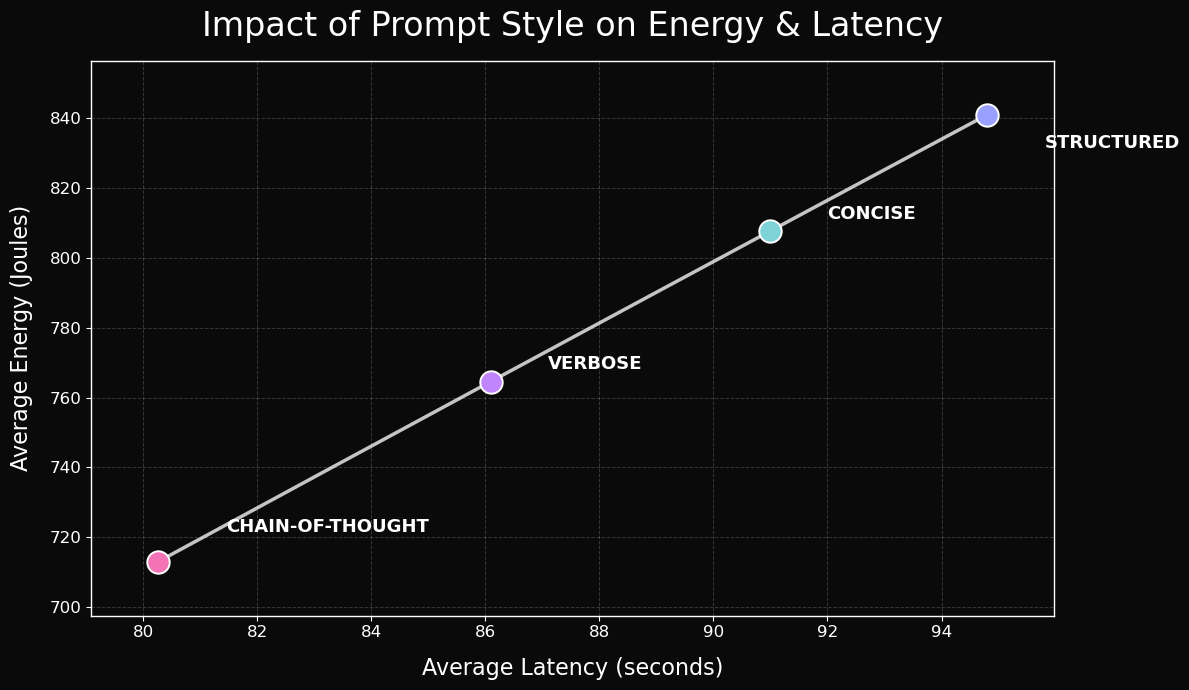

In [31]:
# Color + label maps

color_map = {
    "concise": "#7dd3d8",      # cyan
    "structured": "#9aa0ff",   # soft blue
    "verbose": "#c084fc",      # purple
    "cot": "#f472b6"           # pink
}

label_map = {
    "concise": "CONCISE",
    "structured": "STRUCTURED",
    "verbose": "VERBOSE",
    "cot": "CHAIN-OF-THOUGHT"
}

#  Build plot

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")

x = summary["avg_latency_sec"].to_numpy()
y = summary["avg_energy_joules"].to_numpy()
styles = summary["prompt_style"].astype(str).tolist()

# Smooth curve
if len(x) >= 3:
    coeffs = np.polyfit(x, y, deg=2)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = np.polyval(coeffs, x_smooth)
    ax.plot(
        x_smooth,
        y_smooth,
        color="#cfcfcf",
        linewidth=2.5,
        alpha=0.95,
        zorder=1
    )

# Scatter points + labels
for xi, yi, s in zip(x, y, styles):
    ax.scatter(
        xi,
        yi,
        s=260,
        color=color_map[s],
        edgecolor="white",
        linewidth=1.4,
        zorder=3
    )

    # Slight offsets for readability
    x_offset = 0.8
    y_offset = 0

    if s == "cot":
        x_offset = 1.2
        y_offset = 10
    elif s == "verbose":
        x_offset = 1.0
        y_offset = 5
    elif s == "structured":
        x_offset = 1.0
        y_offset = -8
    elif s == "concise":
        x_offset = 1.0
        y_offset = 5

    ax.text(
        xi + x_offset,
        yi + y_offset,
        label_map[s],
        color="white",
        fontsize=13,
        fontweight="bold",
        va="center"
    )

#  Styling

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.18, color="white")

for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_linewidth(1.0)

ax.tick_params(axis="both", colors="white", labelsize=12)

ax.set_xlabel("Average Latency (seconds)", color="white", fontsize=16, labelpad=12)
ax.set_ylabel("Average Energy (Joules)", color="white", fontsize=16, labelpad=12)
ax.set_title("Impact of Prompt Style on Energy & Latency", color="white", fontsize=24, pad=18)

ax.margins(x=0.08, y=0.12)

plt.tight_layout()

# Save output

plt.savefig(
    "Impact_of_Prompt_Style_on_Energy_&_Latency.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

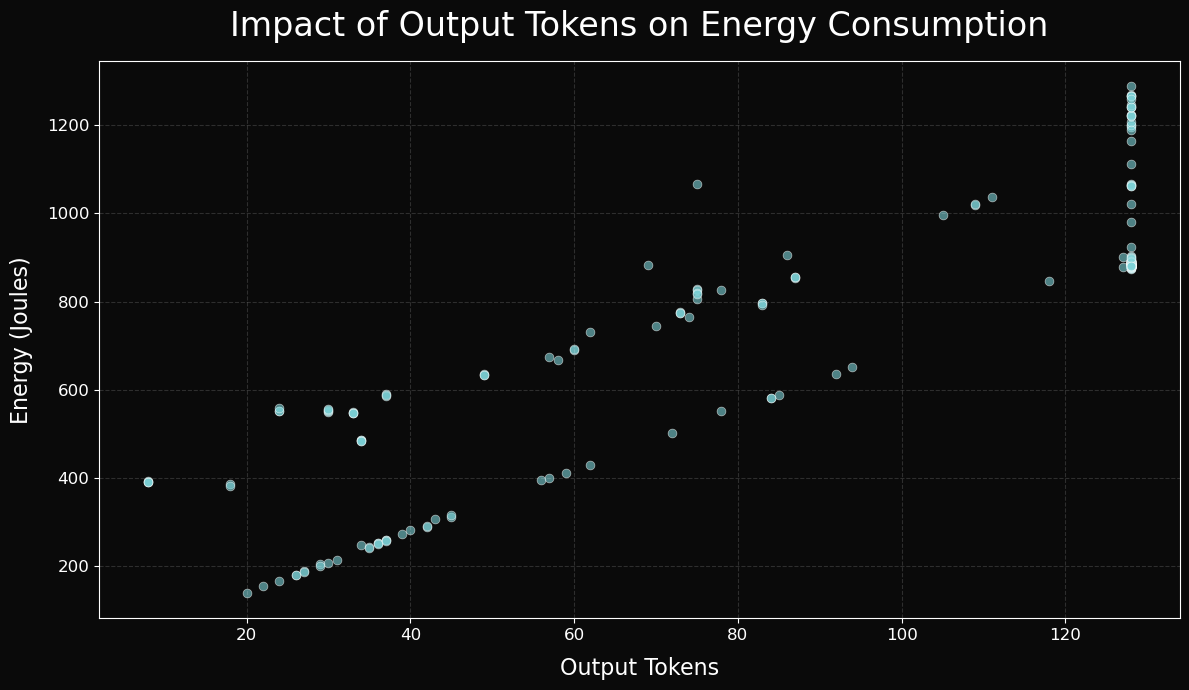

In [37]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

# Load data

df = pd.read_csv("clean_runs.csv")
df = df[df["status"] == "success"]

#  Create figure

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")

# Scatter plot

ax.scatter(
    df["output_tokens"],
    df["energy_joules"],
    s=40,
    color="#7dd3d8",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5
)

# Styling

ax.set_xlabel("Output Tokens", color="white", fontsize=16, labelpad=10)
ax.set_ylabel("Energy (Joules)", color="white", fontsize=16, labelpad=10)
ax.set_title("Impact of Output Tokens on Energy Consumption", color="white", fontsize=24, pad=18)

ax.grid(True, linestyle="--", alpha=0.15, color="white")

for spine in ax.spines.values():
    spine.set_color("white")

ax.tick_params(colors="white", labelsize=12)

plt.tight_layout()

# Save

plt.savefig(
    "output_tokens_vs_energy_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

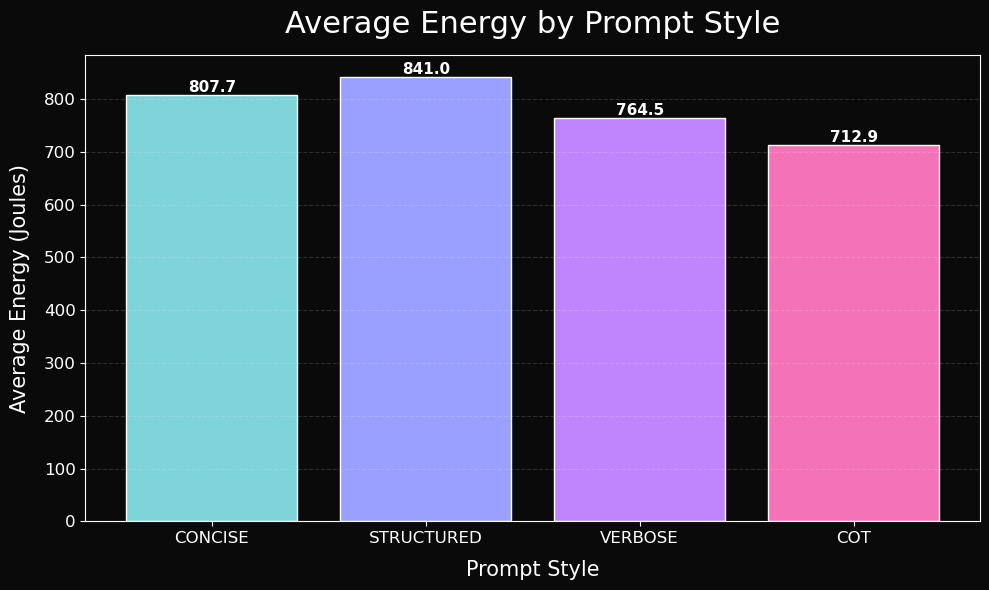

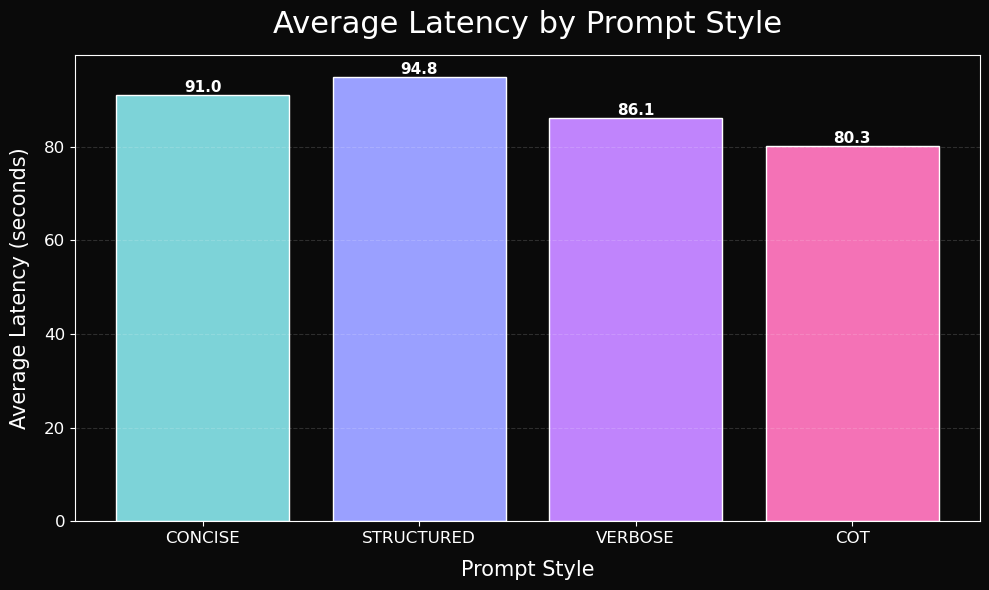

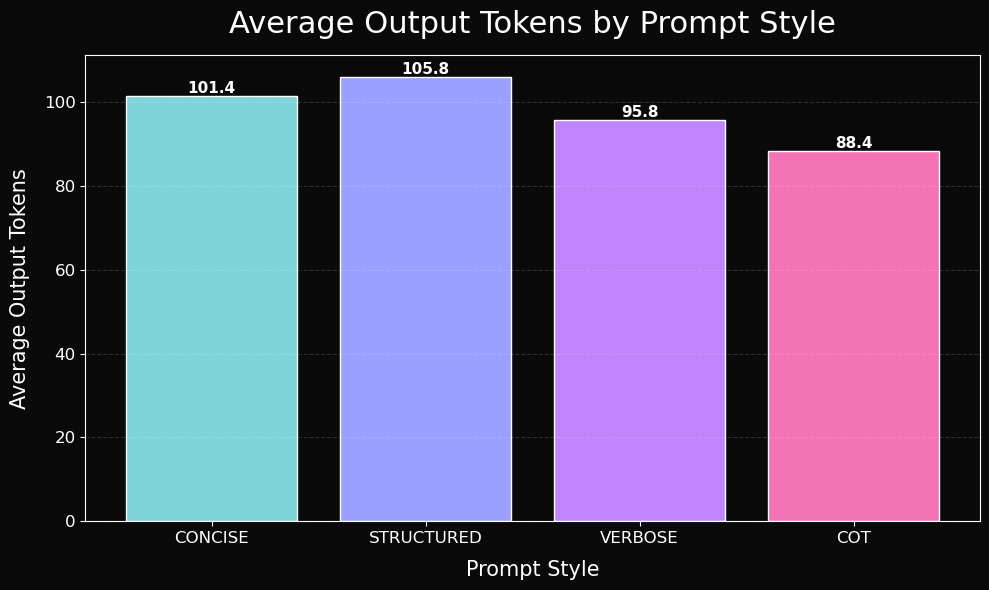

  prompt_style  avg_energy_joules  avg_latency_sec  avg_output_tokens  runs
0      concise         807.679009        90.987454         101.366667    60
2   structured         841.017503        94.802658         105.833333    60
3      verbose         764.498501        86.090911          95.783333    60
1          cot         712.910378        80.252524          88.383333    60


In [38]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("clean_runs.csv")
df = df[df["status"] == "success"].copy()

# Standard prompt order
style_order = ["concise", "structured", "verbose", "cot"]

summary = (
    df.groupby("prompt_style", as_index=False)
      .agg(
          avg_energy_joules=("energy_joules", "mean"),
          avg_latency_sec=("latency_sec", "mean"),
          avg_output_tokens=("output_tokens", "mean"),
          runs=("run_id", "count")
      )
)

summary["prompt_style"] = pd.Categorical(
    summary["prompt_style"],
    categories=style_order,
    ordered=True
)
summary = summary.sort_values("prompt_style")

color_map = {
    "concise": "#7dd3d8",
    "structured": "#9aa0ff",
    "verbose": "#c084fc",
    "cot": "#f472b6"
}

bar_colors = [color_map[s] for s in summary["prompt_style"]]

def make_bar_chart(values_col, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("#0a0a0a")
    ax.set_facecolor("#0a0a0a")

    bars = ax.bar(
        summary["prompt_style"].str.upper(),
        summary[values_col],
        color=bar_colors,
        edgecolor="white",
        linewidth=1.0
    )

    ax.set_xlabel("Prompt Style", color="white", fontsize=15, labelpad=10)
    ax.set_ylabel(ylabel, color="white", fontsize=15, labelpad=10)
    ax.set_title(title, color="white", fontsize=22, pad=16)

    ax.tick_params(colors="white", labelsize=12)
    for spine in ax.spines.values():
        spine.set_color("white")

    ax.grid(axis="y", linestyle="--", alpha=0.15, color="white")

    # Value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            color="white",
            fontsize=11,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

make_bar_chart(
    "avg_energy_joules",
    "Average Energy (Joules)",
    "Average Energy by Prompt Style",
    "avg_energy_by_prompt_style_dark.png"
)

make_bar_chart(
    "avg_latency_sec",
    "Average Latency (seconds)",
    "Average Latency by Prompt Style",
    "avg_latency_by_prompt_style_dark.png"
)

make_bar_chart(
    "avg_output_tokens",
    "Average Output Tokens",
    "Average Output Tokens by Prompt Style",
    "avg_output_tokens_by_prompt_style_dark.png"
)

print(summary)